In [1]:
import numpy as np
import pandas as pd
import pandas_datareader.data as web
import scipy.stats as stats
from scipy import special
from scipy.optimize import minimize
from arch import arch_model
import matplotlib.pyplot as plt

In [2]:
omega=-0.3690
beta=0.0613
alpha=1.5403
nu=6.6390

# Подсчет метрик VaR / CoVaR

Проведем анализ того, как рыночный риск (изменения в Treasury yield DGS10) может влиять на кредитный риск (изменения в спредах AAA10Y).

- **VaR**: безусловный квантиль распределения изменения кредитных спердов 
- **CoVaR**: VaR изменения кредитных спердов обусловленный на экстремальные изменения в Treasury yields

Используем обученные параметры для t-копулы из `copula_comparison.ipynb`.

In [ ]:
# ── Reproduce data pipeline from copula_comparison ──────────────────────────
X = 'DGS10'
Y = 'AAA10Y'

tsy_data = web.DataReader([X, Y], 'fred', start='2000-01-01', end='2026-02-27').dropna()
np.random.seed(42)
tsy_data += np.random.uniform(-0.005, 0.005, size=tsy_data.shape)
tsy_changes = tsy_data.diff().dropna()

results_dict, std_resids = {}, {}
for var in [X, Y]:
    y = tsy_changes[var].values
    res = arch_model(y, mean='Zero', vol='GARCH', p=1, q=1,
                     dist='t', rescale=False).fit(disp='off')
    results_dict[var] = res
    std_resids[var]   = res.resid / res.conditional_volatility

nu_1 = results_dict[X].params['nu']   
nu_2 = results_dict[Y].params['nu']  

u1c = np.clip(stats.t.cdf(std_resids[X], df=nu_1), 1e-6, 1-1e-6)
u2c = np.clip(stats.t.cdf(std_resids[Y], df=nu_2), 1e-6, 1-1e-6)

sigma_1 = results_dict[Y].conditional_volatility 
sigma_2 = results_dict[X].conditional_volatility

T = len(u1c)
print(f'T={T}   nu_DGS10={nu_1:.4f}   nu_AAA10Y={nu_2:.4f}')

T=6535   nu_DGS10=9.6392   nu_AAA10Y=5.1690


In [ ]:
# ── Rebuild time-varying ρ_t from the estimated t-copula ────────────────────
M = 80   

def logistic(x):
    return np.tanh(x / 2.0)

def _rho_path(omega, beta, alpha, z1, z2, m):
    T = len(z1)
    rho = np.empty(T)
    cross = z1 * z2
    rho_prev = float(np.corrcoef(z1, z2)[0, 1])
    for t in range(T):
        avg = 0.0 if t == 0 else (cross[:t].mean() if t < m else cross[t-m:t].mean())
        rho[t] = logistic(omega + beta * rho_prev + alpha * avg)
        rho_prev = rho[t]
    return rho

z1_t = stats.t.ppf(u1c, df=nu) 
z2_t = stats.t.ppf(u2c, df=nu)

rho_t = np.clip(_rho_path(omega, beta, alpha, z1_t, z2_t, M), -0.9999, 0.9999)
print(f'rho_t: mean={rho_t.mean():.4f}  min={rho_t.min():.4f}  max={rho_t.max():.4f}')

rho_t: mean=-0.4458  min=-0.9065  max=-0.0610


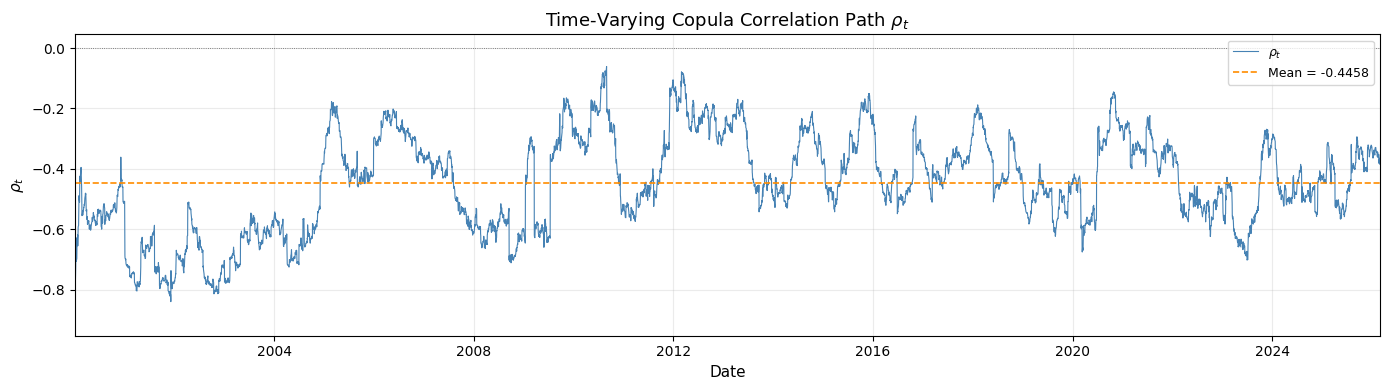

In [20]:
fig, ax = plt.subplots(figsize=(14, 4))

dates = tsy_changes.index

ax.plot(dates, rho_t, color='steelblue', linewidth=0.8, label=r'$\rho_t$')
ax.axhline(rho_t.mean(), color='darkorange', linewidth=1.2, linestyle='--',
           label=f'Mean = {rho_t.mean():.4f}')
ax.axhline(0, color='black', linewidth=0.6, linestyle=':', alpha=0.6)

ax.set_title(r'Time-Varying Copula Correlation Path $\rho_t$', fontsize=13)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel(r'$\rho_t$', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.25)
ax.set_xlim(dates[0], dates[-1])
plt.tight_layout()
plt.show()

Поскольку DGS10 и AAA10Y отрицательно коррелированы, экономически значимым кризисным сценарием является перекрестный сценарий:

$Cross-CoVaR^{U|D}$: верхний хвост распределения кредитных спредов (AAA10Y ↑) при условии падения доходностей Treasuries (DGS10 ↓)

$Cross-CoVaR^{D|U}$: нижний хвост распределения кредитных спредов (AAA10Y ↓) при условии роста доходностей Treasuries (DGS10 ↑)

In [22]:
# ── Unconditional VaR from GARCH-t margin of AAA10Y ─────────────────────────
alpha = 0.05
beta  = 0.05

var_d = sigma_1 * stats.t.ppf(alpha,     df=nu_2) 
var_u = sigma_1 * stats.t.ppf(1 - alpha, df=nu_2)  

def covar_from_rho(rho, z2_q, t_inv_alpha, sigma, nu_cop, nu_margin):
    """
    Closed-form CoVaR / Cross-CoVaR from the conditional bivariate t distribution.

    rho         : (T,) time-varying copula correlation
    z2_q        : scalar — t_nu^{-1}(conditioning quantile)   e.g. t_nu^{-1}(0.05)
    t_inv_alpha : scalar — t_{nu+1}^{-1}(target quantile)     e.g. t_{nu+1}^{-1}(0.95)
    sigma       : (T,) conditional volatility of the target series
    nu_cop      : copula degrees of freedom
    nu_margin   : GARCH-t degrees of freedom for the target margin
    """
    scale   = np.sqrt((1.0 - rho**2) * (nu_cop + z2_q**2) / (nu_cop + 1.0))
    z1_star = rho * z2_q + t_inv_alpha * scale
    u1_star = np.clip(stats.t.cdf(z1_star, df=nu_cop), 1e-9, 1-1e-9)
    return sigma * stats.t.ppf(u1_star, df=nu_margin)

z2_down       = stats.t.ppf(beta,       df=nu)
t_inv_hi      = stats.t.ppf(1 - alpha,  df=nu + 1)

cross_covar_ud = covar_from_rho(rho_t, z2_down, t_inv_hi, sigma_1, nu, nu_2)

z2_up         = stats.t.ppf(1 - beta,   df=nu)
t_inv_lo      = stats.t.ppf(alpha,      df=nu + 1)

cross_covar_du = covar_from_rho(rho_t, z2_up, t_inv_lo, sigma_1, nu, nu_2)

# Тест Колмогорова–Смирнова 

Для проверки гипотезы о наличии влияния хвостового риска применяется односторонний тест Колмогорова–Смирнова (KS-тест), аналогично подходу, используемому в статье Gao et al.

Нулевая гипотеза H₀: распределения CoVaR и VaR совпадают, то есть условие на экстремальное состояние рынка Treasury yields не влияет на распределение риска кредитных спредов.

Альтернативные гипотезы:

U|D: $Cross-CoVaR^{U|D}$ стохастически больше $VaR^U$ — при падении доходностей в нижний хвост кредитные спреды испытывают бо́льший риск роста, чем в безусловном случае

D|U: $Cross-CoVaR^{D|U}$ стохастически меньше $VaR^D$ — при росте доходностей в верхний хвост кредитные спреды испытывают бо́льший риск падения, чем в безусловном случае

In [23]:
from scipy.stats import ks_2samp


stat_ud, p_ud = ks_2samp(var_u, cross_covar_ud, alternative='greater')
stat_du, p_du = ks_2samp(var_d, cross_covar_du, alternative='less')

results = pd.DataFrame({
    'H₁':           ['CoVaR^{U|D} > VaR^U  (stoch. greater)',
                      'CoVaR^{D|U} < VaR^D  (stoch. less)'],
    'KS stat':      [stat_ud, stat_du],
    'p-value':      [p_ud,    p_du],
    'Reject H₀ 5%': [p_ud < 0.05, p_du < 0.05],
}, index=['U|D  (spread↑ | yield↓)', 'D|U  (spread↓ | yield↑)'])

results

,H₁,KS stat,p-value,Reject H₀ 5%
U|D (spread↑ | yield↓),CoVaR^{U|D} > VaR^U (stoch. greater),0.489365,0.0,True
D|U (spread↓ | yield↑),CoVaR^{D|U} < VaR^D (stoch. less),0.489365,0.0,True


In [24]:
for label, row in results.iterrows():
    verdict = "REJECT H0 — spillover confirmed" if row['Reject H₀ 5%'] else "Fail to reject H0"
    print(f"  {label}: {verdict}  (p={row['p-value']:.4e})")

  U|D  (spread↑ | yield↓): REJECT H0 — spillover confirmed  (p=0.0000e+00)
  D|U  (spread↓ | yield↑): REJECT H0 — spillover confirmed  (p=0.0000e+00)


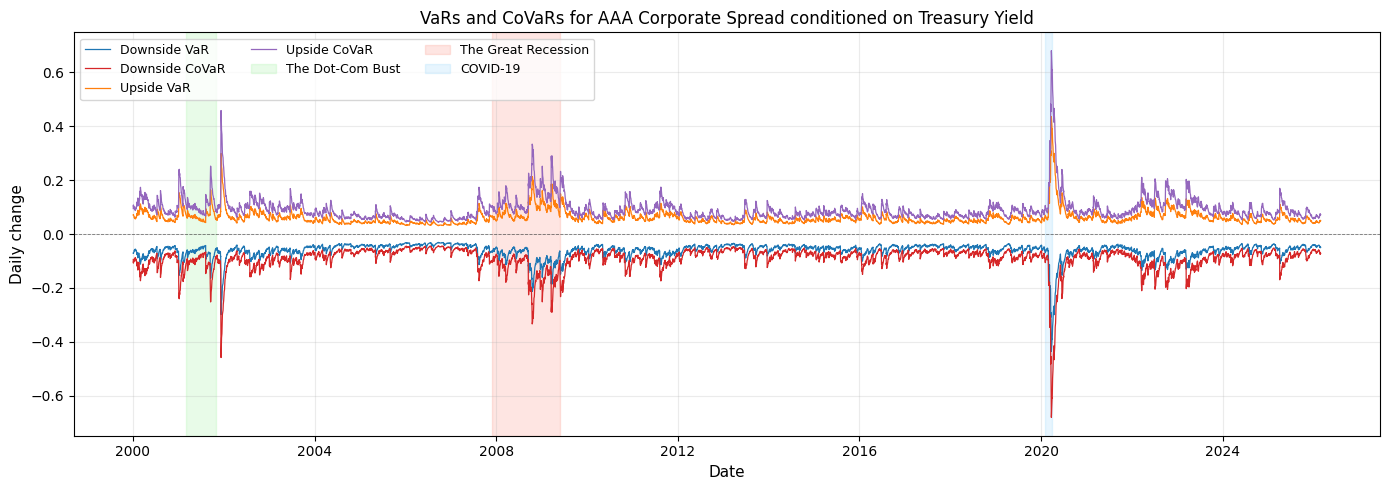

In [25]:
dates = tsy_changes.index
crises = [
    ('2001-03-01', '2001-11-01', 'lightgreen', 'The Dot-Com Bust'),
    ('2007-12-01', '2009-06-01', 'salmon', 'The Great Recession'),
    ('2020-02-01', '2020-04-01', 'lightskyblue', 'COVID-19'),
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dates, var_d,          color='#1f77b4', lw=0.9, label='Downside VaR')
ax.plot(dates, cross_covar_du, color='#d62728', lw=0.9, label='Downside CoVaR')
ax.plot(dates, var_u,          color='#ff7f0e', lw=0.9, label='Upside VaR')
ax.plot(dates, cross_covar_ud, color='#9467bd', lw=0.9, label='Upside CoVaR')

for s, e, c, n in crises:
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.20, color=c, label=n)

ax.axhline(0, color='black', lw=0.6, ls='--', alpha=0.5)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Daily change', fontsize=11)
ax.set_title('VaRs and CoVaRs for AAA Corporate Spread conditioned on Treasury Yield', fontsize=12)
ax.legend(fontsize=9, loc='upper left', ncol=3)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()